# CivicPulse AI
## AI-Powered Urban Problem Intelligence Engine

### Problem Statement

Urban authorities receive large volumes of citizen complaints
covering issues such as roads, sanitation, water, drainage,
electricity and public infrastructure.

Analyzing these complaints manually makes it difficult to identify
emerging trends, geographical hotspots and recurring problems.

CivicPulse AI uses data analytics, NLP, geospatial analysis and
machine learning to transform complaint data into actionable
urban insights.

## 1. Project Objectives

The main objectives of CivicPulse AI are:

1. Analyze urban service-request patterns.
2. Identify the most common urban problems.
3. Analyze complaint trends over time.
4. Automatically classify complaint descriptions using NLP.
5. Detect geographical complaint hotspots.
6. Develop an Urban Problem Score for comparative analysis.
7. Predict future complaint volume using machine learning.
8. Generate data-driven AI insights from analytical results.

## 2. Dataset

CivicPulse AI uses the NYC 311 Service Requests from 2020 to Present
dataset published by NYC OpenData.

The dataset contains service requests submitted through the NYC 311
system and includes information about problem types, responding
agencies, dates, status and geographic location.

Dataset Source:

https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9

In [162]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

import os
os.makedirs("outputs/figures", exist_ok=True)


In [163]:
import requests
base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

params = {
    "$limit": 500000,
    "$order": "created_date ASC"
}

response = requests.get(base_url, params=params)

print("Status code:", response.status_code)

response.raise_for_status()

data = response.json()

df = pd.DataFrame(data)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Status code: 200
Dataset loaded successfully.
Shape: (500000, 44)


In [164]:
df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,status,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,descriptor_2,taxi_pick_up_location,facility_type,taxi_company_borough,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,due_date,vehicle_type
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Restaurant/Bar/Deli/Bakery,11229,3442 NOSTRAND AVENUE,NOSTRAND AVENUE,GRAVESEND NECK ROAD,AVENUE V,GRAVESEND NECK ROAD,AVENUE V,ADDRESS,BROOKLYN,NOSTRAND AVENUE,Closed,The Health Departmentâs Office of Environmental Investigations has determined this case was an...,2020-01-10T16:38:17.000,15 BROOKLYN,46,Precinct 61,3073620008,BROOKLYN,1000400,157925,ONLINE,Unspecified,BROOKLYN,40.6001292057807,-73.94184291675883,"{'type': 'Point', 'coordinates': [-73.941842916759, 40.600129205781]}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,45287907,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Restaurant/Bar/Deli/Bakery,11214,1602 SHORE PARKWAY,SHORE PARKWAY,BELT PARKWAY EXIT 5 EASTBOUND,BELT PARKWAY EB EN BAY PKWY,BELT PARKWAY EXIT 5 EASTBOUND,BELT PARKWAY EB EN BAY PKWY,ADDRESS,BROOKLYN,SHORE PARKWAY,Closed,The Department of Health and Mental Hygiene has determined that the reported incident is isolate...,2020-01-15T16:51:03.000,11 BROOKLYN,43,Precinct 62,3064910050,BROOKLYN,984202,156289,ONLINE,Unspecified,BROOKLYN,40.59565343138651,-74.00017283917487,"{'type': 'Point', 'coordinates': [-74.000172839175, 40.595653431387]}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,45288240,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Restaurant/Bar/Deli/Bakery,11385,1717 CORNELIA STREET,CORNELIA STREET,MYRTLE AVENUE,SENECA AVENUE,MYRTLE AVENUE,SENECA AVENUE,ADDRESS,Ridgewood,CORNELIA STREET,Closed,The Department of Health and Mental Hygiene has determined that the reported incident is isolate...,2020-01-15T16:44:34.000,05 QUEENS,34,Precinct 104,4034610052,QUEENS,1010470,194453,ONLINE,Unspecified,QUEENS,40.700366489799876,-73.90543829006366,"{'type': 'Point', 'coordinates': [-73.905438290064, 40.7003664898]}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,45289555,2020-01-01T00:00:00.000,2020-01-02T09:39:33.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Restaurant/Bar/Deli/Bakery,11421,92-20 JAMAICA AVENUE,JAMAICA AVENUE,92 STREET,WOODHAVEN BOULEVARD,92 STREET,WOODHAVEN BOULEVARD,ADDRESS,Woodhaven,JAMAICA AVENUE,Closed,The Department of Health and Mental Hygiene has determined that the reported incident is isolate...,2020-01-02T09:39:33.000,09 QUEENS,32,Precinct 102,4089330077,QUEENS,1025018,191916,ONLINE,Unspecified,QUEENS,40.69334796062744,-73.85298676420625,"{'type': 'Point', 'coordinates': [-73.852986764206, 40.693347960627]}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Other (Explain Below),11203,5707 CHURCH AVENUE,CHURCH AVENUE,EAST 57 STREET,KINGS HIGHWAY,EAST 57 STREET,KINGS HIGHWAY,ADDRESS,BROOKLYN,CHURCH AVENUE,Closed,The Health Departmentâs Office of Environmental Investigations has determined this case was an...,2020-01-02T09:50:00.000,17 BROOKLYN,41,Precinct 67,NaN,BROOKLYN,1005466,177022,ONLINE,Unspecified,BROOKLYN,40.65253575905768,-73.92353994017134,"{'type': 'Point', 'coordinates': [-73.923539940171, 40.652535759058]}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,45288120,2020-01-

In [165]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 500000
Number of columns: 44


In [166]:
df.columns.tolist()

['unique_key',
 'created_date',
 'closed_date',
 'agency',
 'agency_name',
 'complaint_type',
 'descriptor',
 'location_type',
 'incident_zip',
 'incident_address',
 'street_name',
 'cross_street_1',
 'cross_street_2',
 'intersection_street_1',
 'intersection_street_2',
 'address_type',
 'city',
 'landmark',
 'status',
 'resolution_description',
 'resolution_action_updated_date',
 'community_board',
 'council_district',
 'police_precinct',
 'bbl',
 'borough',
 'x_coordinate_state_plane',
 'y_coordinate_state_plane',
 'open_data_channel_type',
 'park_facility_name',
 'park_borough',
 'latitude',
 'longitude',
 'location',
 'descriptor_2',
 'taxi_pick_up_location',
 'facility_type',
 'taxi_company_borough',
 'bridge_highway_name',
 'bridge_highway_direction',
 'road_ramp',
 'bridge_highway_segment',
 'due_date',
 'vehicle_type']

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   unique_key                      500000 non-null  str   
 1   created_date                    500000 non-null  str   
 2   closed_date                     495213 non-null  str   
 3   agency                          500000 non-null  str   
 4   agency_name                     500000 non-null  str   
 5   complaint_type                  500000 non-null  str   
 6   descriptor                      499999 non-null  str   
 7   location_type                   370069 non-null  str   
 8   incident_zip                    485334 non-null  str   
 9   incident_address                467082 non-null  str   
 10  street_name                     467068 non-null  str   
 11  cross_street_1                  350708 non-null  str   
 12  cross_street_2                  350104 no

## 3. Initial Data Understanding

The first step in the analytical workflow is to understand the
structure, data types, missing values and distribution of the
available variables.

This helps identify data-quality issues before performing
statistical analysis or machine learning.

In [168]:
numeric_cols = df.select_dtypes(include="number").columns

summary = pd.DataFrame({
    "Count": df[numeric_cols].count(),
    "Mean": df[numeric_cols].mean(),
    "Std": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max()
})

summary

,Count,Mean,Std,Min,Max


In [169]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df) * 100).round(2)
})

missing_df.head(20)

,Missing Values,Missing Percentage
vehicle_type,499793,99.96
taxi_company_borough,499594,99.92
bridge_highway_segment,499209,99.84
road_ramp,499209,99.84
bridge_highway_name,499207,99.84
bridge_highway_direction,499206,99.84
due_date,496998,99.40
taxi_pick_up_location,492066,98.41
facility_type,441493,88.30
descriptor_2,299042,59.81


In [170]:
duplicate_count = df.astype(str).duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [171]:
for column in ["complaint_type", "agency", "status", "borough"]:
    if column in df.columns:
        print("\n", column)
        print(df[column].nunique(), "unique values")


 complaint_type
176 unique values

 agency
15 unique values

 status
7 unique values

 borough
6 unique values


## 4. Data Cleaning

The dataset is cleaned before analysis by:

- converting date fields into datetime format
- removing duplicate records
- handling missing categorical values
- converting geographic fields to numeric values
- creating derived time-based variables
- preparing textual fields for NLP

In [172]:
df["created_date"] = pd.to_datetime(
    df["created_date"],
    errors="coerce"
)

df["closed_date"] = pd.to_datetime(
    df["closed_date"],
    errors="coerce"
)

print(df[["created_date", "closed_date"]].dtypes)

created_date    datetime64[us]
closed_date     datetime64[us]
dtype: object


In [173]:
before = len(df)

df = df.drop_duplicates(subset=["unique_key"])

after = len(df)

print("Records before:", before)
print("Records after:", after)
print("Duplicates removed:", before - after)

Records before: 500000
Records after: 500000
Duplicates removed: 0


In [174]:
categorical_columns = [
    "complaint_type",
    "descriptor",
    "agency",
    "agency_name",
    "status",
    "borough",
    "location_type"
]

for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")
        df[column] = df[column].astype(str).str.strip()

In [175]:
df["latitude"] = pd.to_numeric(
    df["latitude"],
    errors="coerce"
)

df["longitude"] = pd.to_numeric(
    df["longitude"],
    errors="coerce"
)

print(df[["latitude", "longitude"]].describe())

            latitude      longitude
count  482786.000000  482786.000000
mean       40.727079     -73.925529
std         0.085647       0.084094
min        40.499212     -74.254604
25%        40.665482     -73.973455
50%        40.719152     -73.927938
75%        40.797232     -73.876265
max        40.912869     -73.700767


In [176]:
df["resolution_hours"] = (
    df["closed_date"] - df["created_date"]
).dt.total_seconds() / 3600

df["resolution_hours"] = df["resolution_hours"].where(
    df["resolution_hours"] >= 0
)

df["resolution_hours"].describe()

count    492030.000000
mean        822.015393
std        4606.507954
min           0.000000
25%           3.039167
50%          24.000000
75%          91.359653
max       58542.326111
Name: resolution_hours, dtype: float64

In [177]:
df["date"] = df["created_date"].dt.date
df["year"] = df["created_date"].dt.year
df["month"] = df["created_date"].dt.month
df["month_name"] = df["created_date"].dt.month_name()
df["day_of_week"] = df["created_date"].dt.day_name()
df["hour"] = df["created_date"].dt.hour

## 5. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the major
patterns in urban service requests.

The analysis focuses on:

- problem categories
- agencies
- complaint status
- geographical distribution
- resolution time
- temporal trends

In [178]:
top_complaints = (
    df["complaint_type"]
    .value_counts()
    .head(15)
)

top_complaints

complaint_type
HEAT/HOT WATER                         57097
Noise - Residential                    50639
Request Large Bulky Item Collection    45888
Illegal Parking                        42801
Blocked Driveway                       28016
Street Condition                       18322
Street Light Condition                 15273
Electronics Waste Appointment          10927
Noise                                  10328
Missed Collection (All Materials)       9596
Water System                            9455
Abandoned Vehicle                       9243
Noise - Street/Sidewalk                 9154
General Construction/Plumbing           9061
UNSANITARY CONDITION                    8294
Name: count, dtype: int64

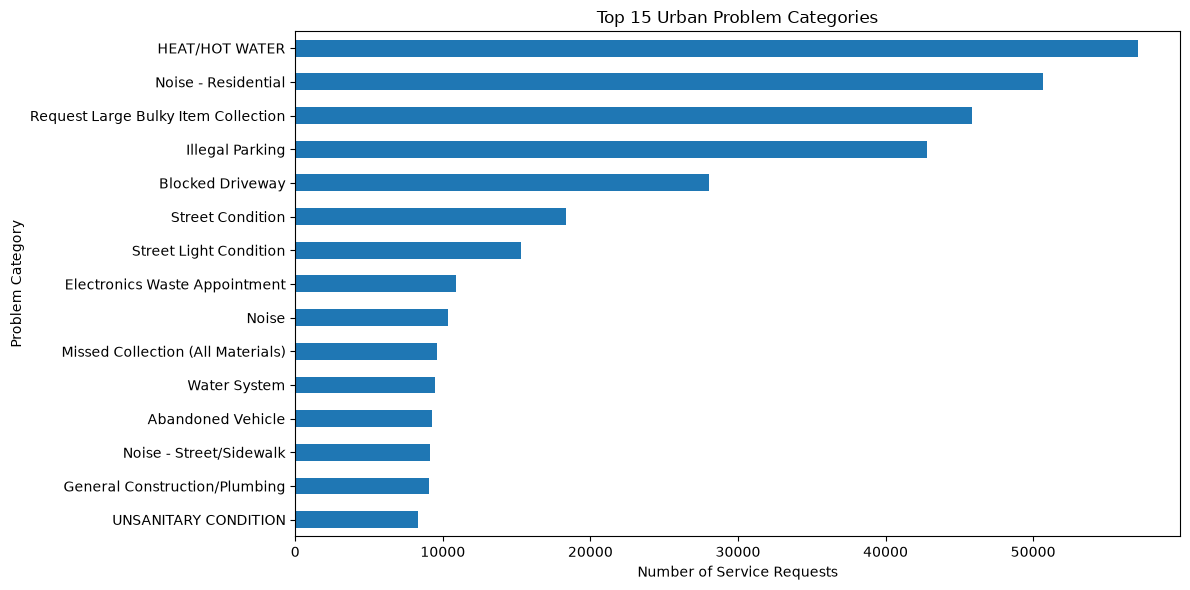

In [179]:
plt.figure(figsize=(12, 6))

top_complaints.sort_values().plot(kind="barh")

plt.title("Top 15 Urban Problem Categories")
plt.xlabel("Number of Service Requests")
plt.ylabel("Problem Category")

plt.tight_layout()

plt.savefig(
    "outputs/figures/complaint_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [180]:
status_counts = df["status"].value_counts()

status_counts

status
Closed         491883
In Progress      4024
Pending          3680
Open              257
Started           105
Assigned           50
Cancel              1
Name: count, dtype: int64

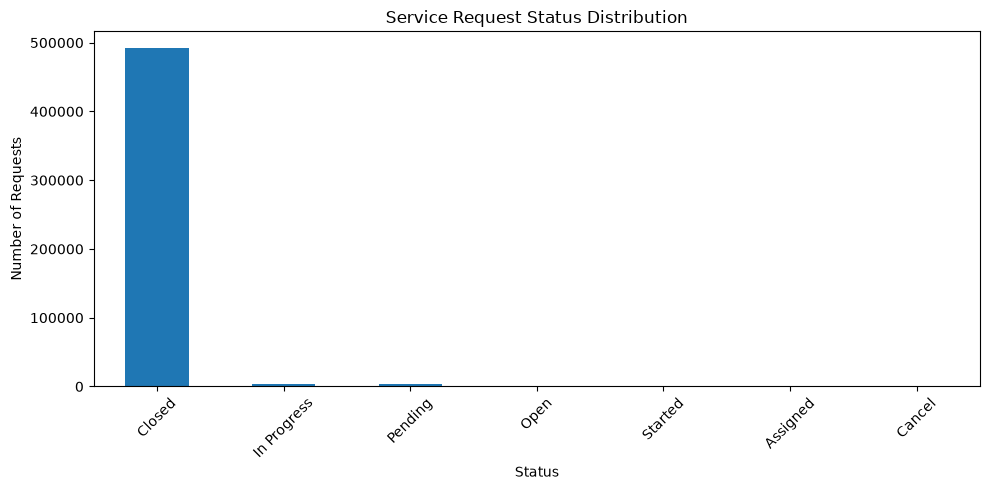

In [181]:
plt.figure(figsize=(10, 5))

status_counts.plot(kind="bar")

plt.title("Service Request Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [182]:
agency_counts = (
    df["agency_name"]
    .value_counts()
    .head(15)
)

agency_counts

agency_name
New York City Police Department                                163997
Department of Sanitation                                        93224
Department of Housing Preservation and Development              90239
Department of Transportation                                    56727
Department of Environmental Protection                          30122
Department of Buildings                                         19893
Department of Health and Mental Hygiene                         12004
Department of Parks and Recreation                              11464
Department of Consumer Affairs                                   8044
Taxi and Limousine Commission                                    8017
Department of Homeless Services                                  3916
Economic Development Corporation                                 1735
Department of Education                                           481
Department of Information Technology and Telecommunications        91
Departme

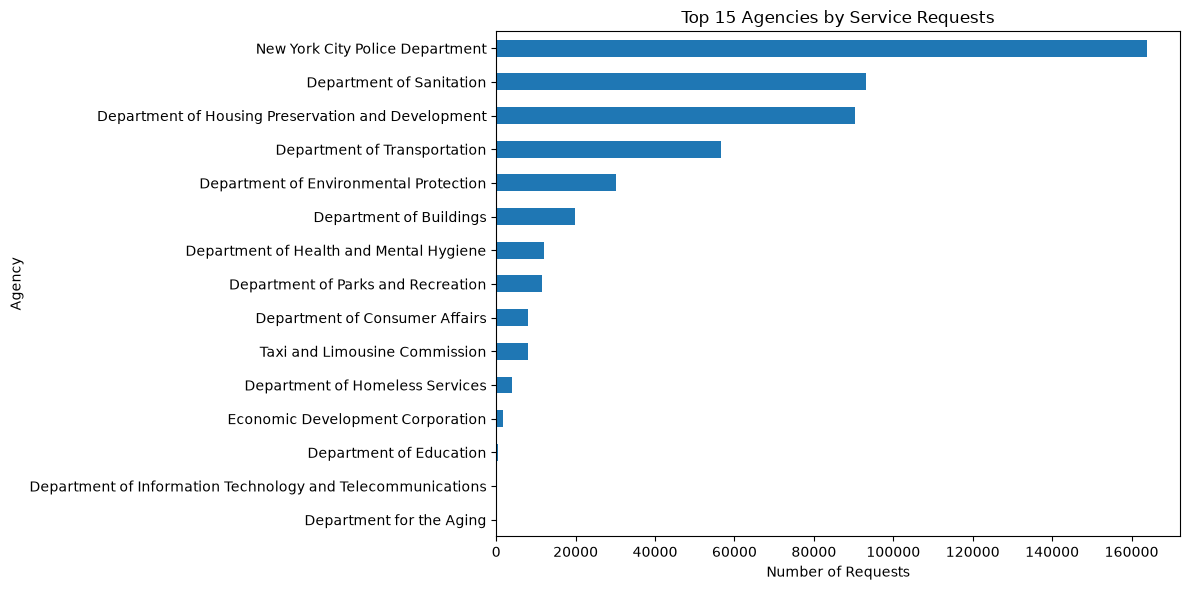

In [183]:
plt.figure(figsize=(12, 6))

agency_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Agencies by Service Requests")
plt.xlabel("Number of Requests")
plt.ylabel("Agency")

plt.tight_layout()
plt.show()

## 6. Temporal Trend Analysis

Temporal analysis identifies how urban service requests change
over time.

This allows CivicPulse AI to identify increasing or decreasing
problem patterns.

In [184]:
monthly_complaints = (
    df.set_index("created_date")
      .resample("ME")
      .size()
)

monthly_complaints.head()

created_date
2020-01-31    195231
2020-02-29    173162
2020-03-31    131607
Freq: ME, dtype: int64

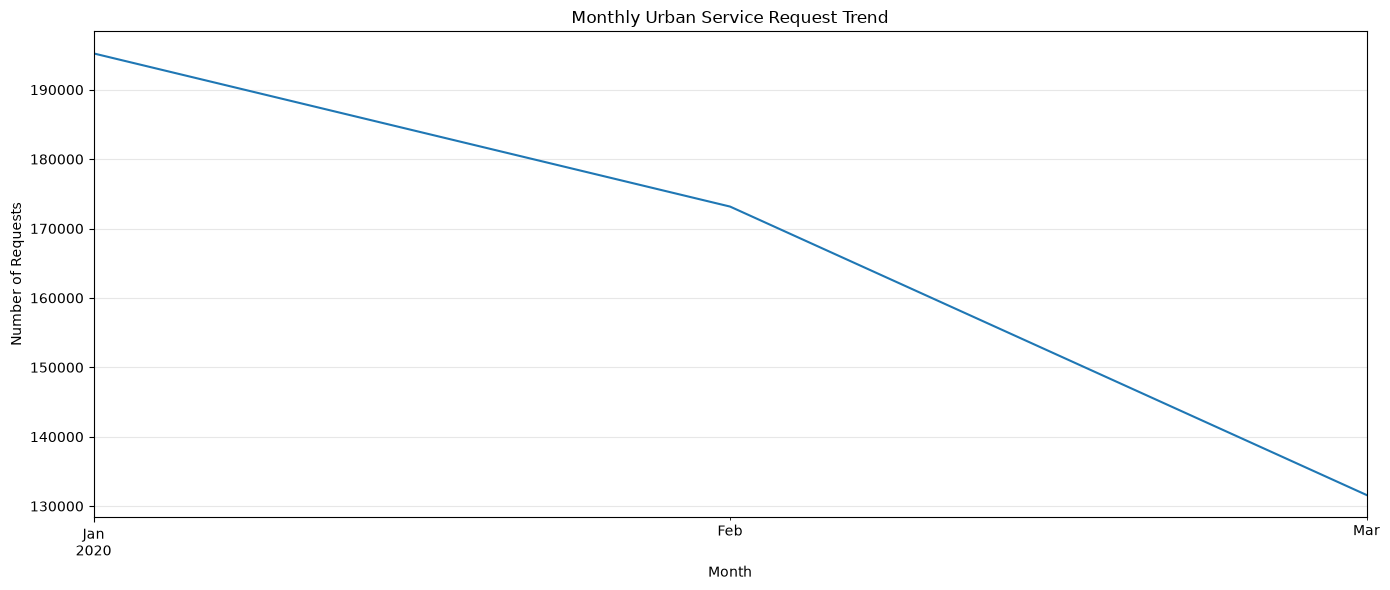

In [185]:
plt.figure(figsize=(14, 6))

monthly_complaints.plot()

plt.title("Monthly Urban Service Request Trend")
plt.xlabel("Month")
plt.ylabel("Number of Requests")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [186]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = (
    df["day_of_week"]
    .value_counts()
    .reindex(day_order)
)

day_counts

day_of_week
Monday       71399
Tuesday      72865
Wednesday    76289
Thursday     79223
Friday       75878
Saturday     66153
Sunday       58193
Name: count, dtype: int64

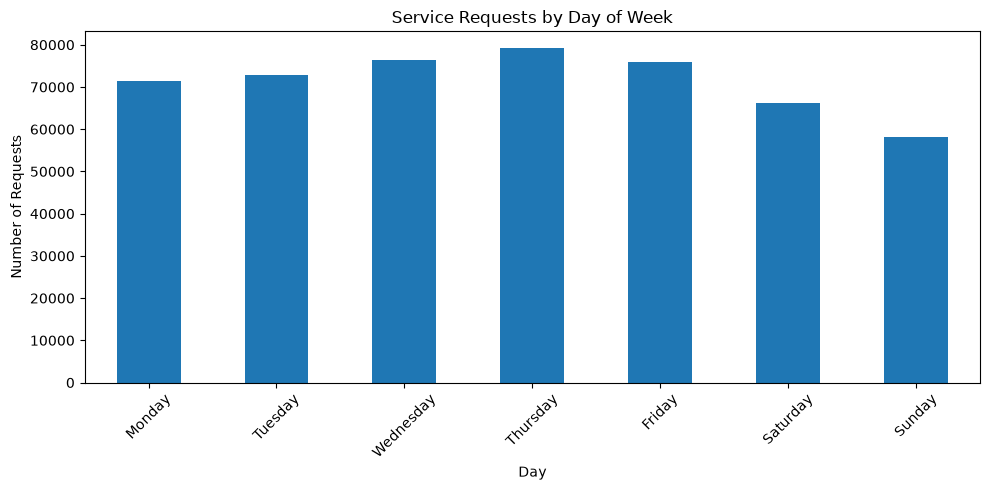

In [187]:
plt.figure(figsize=(10, 5))

day_counts.plot(kind="bar")

plt.title("Service Requests by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [188]:
borough_counts = df["borough"].value_counts()

borough_counts

borough
BROOKLYN         153112
QUEENS           126365
MANHATTAN         98975
BRONX             88370
STATEN ISLAND     27394
Unknown            3323
Unspecified        2461
Name: count, dtype: int64

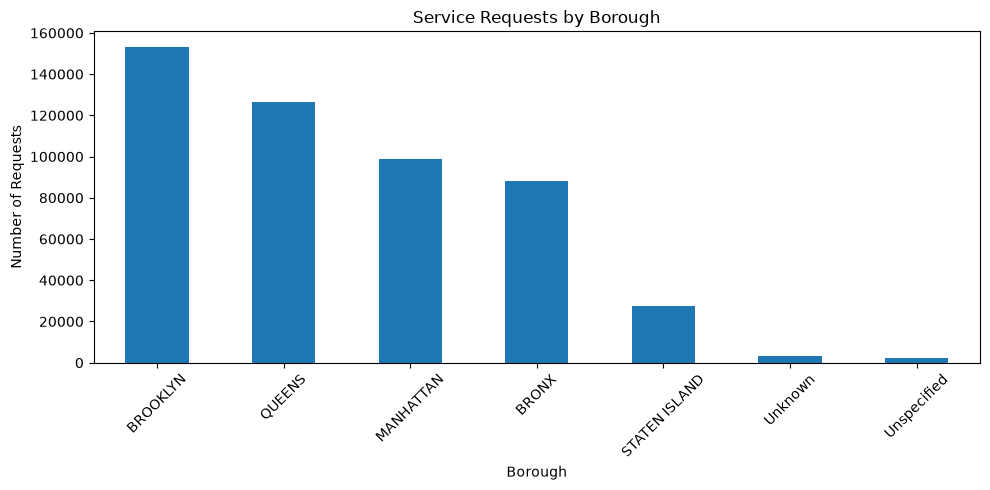

In [189]:
plt.figure(figsize=(10, 5))

borough_counts.plot(kind="bar")

plt.title("Service Requests by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Resolution Time Analysis

Resolution time represents the approximate time between creation
and closure of a service request.

This metric is used to understand operational delays and will later
contribute to the Urban Problem Score.

In [190]:
resolution_clean = df[
    df["resolution_hours"].notna()
    & (df["resolution_hours"] >= 0)
    & (df["resolution_hours"] <= 720)
].copy()

print("Records available for resolution analysis:",
      len(resolution_clean))

Records available for resolution analysis: 454531


In [191]:
resolution_clean["resolution_hours"].describe()

count    454531.000000
mean         60.387926
std         107.940657
min           0.000000
25%           2.621111
50%          19.383333
75%          67.144444
max         720.000000
Name: resolution_hours, dtype: float64

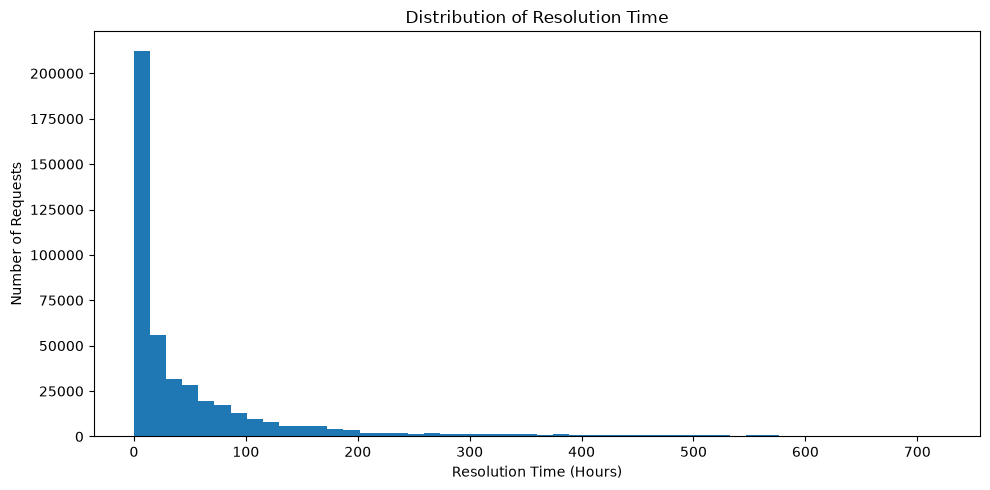

In [192]:
plt.figure(figsize=(10, 5))

plt.hist(
    resolution_clean["resolution_hours"],
    bins=50
)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Number of Requests")

plt.tight_layout()
plt.show()

In [193]:
resolution_by_problem = (
    resolution_clean
    .groupby("complaint_type")["resolution_hours"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

resolution_by_problem

complaint_type
X-Ray Machine/Equipment                 708.394167
Facades                                 612.597778
Bottled Water                           567.286111
Bike Rack Condition                     448.736722
LinkNYC                                 388.864788
Drinking Water                          361.127579
Executive Inspections                   355.853333
Day Care                                353.250345
Special Natural Area District (SNAD)    340.975000
Taxi Complaint                          325.254505
For Hire Vehicle Report                 290.333627
Public Payphone Complaint               287.472815
Bus Stop Shelter Complaint              278.718905
UNSANITARY CONDITION                    268.178021
For Hire Vehicle Complaint              265.711903
Name: resolution_hours, dtype: float64

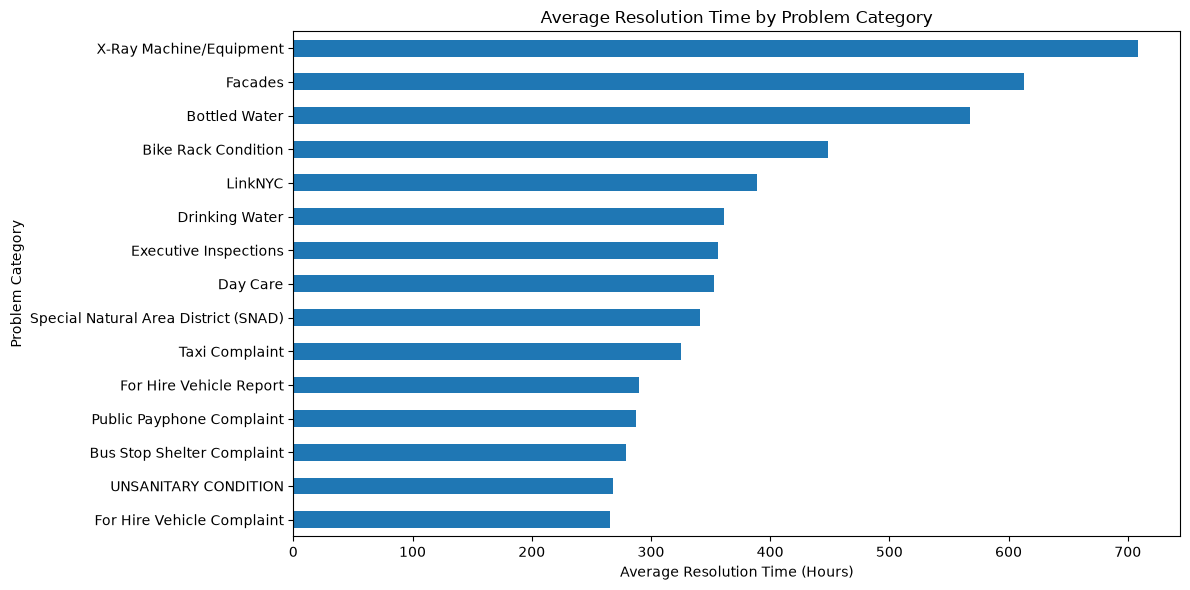

In [194]:
plt.figure(figsize=(12, 6))

resolution_by_problem.sort_values().plot(kind="barh")

plt.title("Average Resolution Time by Problem Category")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Problem Category")

plt.tight_layout()
plt.show()

## 8. NLP-Based Complaint Analysis

Natural Language Processing is used to analyze textual information
associated with service requests.

The Problem Detail field provides additional textual information
about the reported issue.

TF-IDF is used to transform text into numerical features, followed
by Logistic Regression for classification.

In [195]:
nlp_df = df[
    ["descriptor", "complaint_type"]
].copy()

nlp_df["descriptor"] = (
    nlp_df["descriptor"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

nlp_df["complaint_type"] = (
    nlp_df["complaint_type"]
    .fillna("Unknown")
    .astype(str)
)

nlp_df = nlp_df[
    nlp_df["descriptor"].str.len() > 3
]

nlp_df.head()

,descriptor,complaint_type
0,3 or more,Food Poisoning
1,3 or more,Food Poisoning
2,1 or 2,Food Poisoning
3,1 or 2,Food Poisoning
4,1 or 2,Food Poisoning


In [196]:
category_counts = nlp_df["complaint_type"].value_counts()

valid_categories = category_counts[
    category_counts >= 100
].index

nlp_df = nlp_df[
    nlp_df["complaint_type"].isin(valid_categories)
].copy()

print("Number of categories:", nlp_df["complaint_type"].nunique())
print("Number of records:", len(nlp_df))

Number of categories: 99
Number of records: 490910


In [197]:
top_categories = (
    nlp_df["complaint_type"]
    .value_counts()
    .head(10)
    .index
)

nlp_model_df = nlp_df[
    nlp_df["complaint_type"].isin(top_categories)
].copy()

print(nlp_model_df["complaint_type"].value_counts())

complaint_type
HEAT/HOT WATER                         57097
Noise - Residential                    50639
Request Large Bulky Item Collection    45888
Illegal Parking                        42801
Blocked Driveway                       28016
Street Condition                       18322
Street Light Condition                 15273
Electronics Waste Appointment          10927
Noise                                  10328
Missed Collection (All Materials)       9596
Name: count, dtype: int64


In [198]:
X_text = nlp_model_df["descriptor"]
y_text = nlp_model_df["complaint_type"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=42,
    stratify=y_text
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)

Training matrix: (231109, 356)
Testing matrix: (57778, 356)


In [199]:
nlp_model = LogisticRegression(
    max_iter=1000
)

nlp_model.fit(
    X_train_tfidf,
    y_train_text
)

nlp_predictions = nlp_model.predict(
    X_test_tfidf
)

In [200]:
nlp_accuracy = accuracy_score(
    y_test_text,
    nlp_predictions
)

print("NLP Classification Accuracy:",
      round(nlp_accuracy, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_text,
        nlp_predictions,
        zero_division=0
    )
)

NLP Classification Accuracy: 1.0

Classification Report:

                                     precision    recall  f1-score   support

                   Blocked Driveway       1.00      1.00      1.00      5603
      Electronics Waste Appointment       1.00      1.00      1.00      2185
                     HEAT/HOT WATER       1.00      1.00      1.00     11420
                    Illegal Parking       1.00      1.00      1.00      8560
  Missed Collection (All Materials)       1.00      1.00      1.00      1919
                              Noise       1.00      1.00      1.00      2066
                Noise - Residential       1.00      1.00      1.00     10128
Request Large Bulky Item Collection       1.00      1.00      1.00      9178
                   Street Condition       1.00      1.00      1.00      3664
             Street Light Condition       1.00      1.00      1.00      3055

                           accuracy                           1.00     57778
                

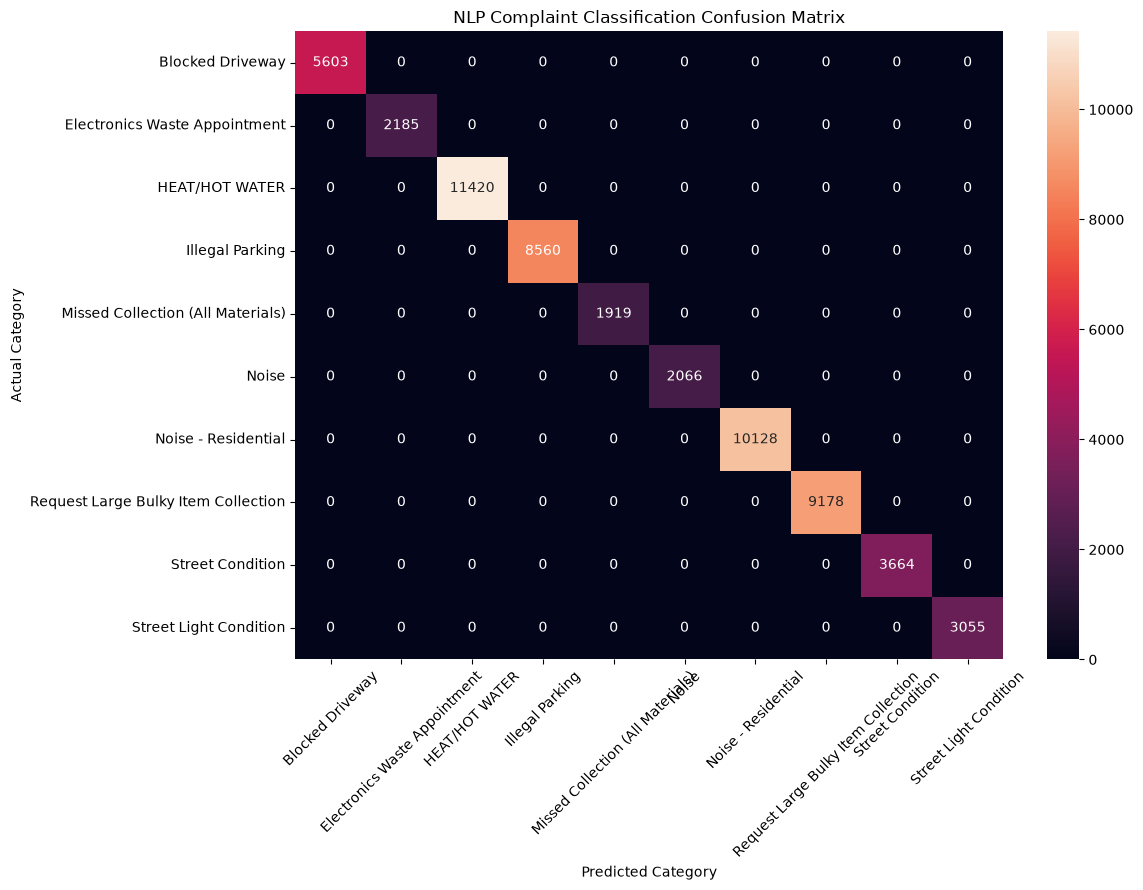

In [201]:
cm = confusion_matrix(
    y_test_text,
    nlp_predictions,
    labels=nlp_model.classes_
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=nlp_model.classes_,
    yticklabels=nlp_model.classes_
)

plt.title("NLP Complaint Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [202]:
sample_complaints = [
    "There is a large problem reported in the neighborhood",
    "The street condition needs attention",
    "There is a complaint about public infrastructure"
]

sample_vectors = tfidf.transform(sample_complaints)

predicted_categories = nlp_model.predict(sample_vectors)

for text, prediction in zip(
    sample_complaints,
    predicted_categories
):
    print("Complaint:", text)
    print("Predicted category:", prediction)
    print()

Complaint: There is a large problem reported in the neighborhood
Predicted category: Request Large Bulky Item Collection

Complaint: The street condition needs attention
Predicted category: Street Condition

Complaint: There is a complaint about public infrastructure
Predicted category: Street Condition



## 9. Geospatial Analysis

Geospatial analysis is used to identify areas where service
requests are concentrated.

Latitude and longitude coordinates are analyzed to identify
spatial clusters that may represent complaint hotspots.

In [203]:
geo_df = df[
    ["unique_key",
     "complaint_type",
     "borough",
     "latitude",
     "longitude"]
].copy()

geo_df["latitude"] = pd.to_numeric(
    geo_df["latitude"],
    errors="coerce"
)

geo_df["longitude"] = pd.to_numeric(
    geo_df["longitude"],
    errors="coerce"
)

geo_df = geo_df.dropna(
    subset=["latitude", "longitude"]
)

print("Geographic records:", len(geo_df))

Geographic records: 482786


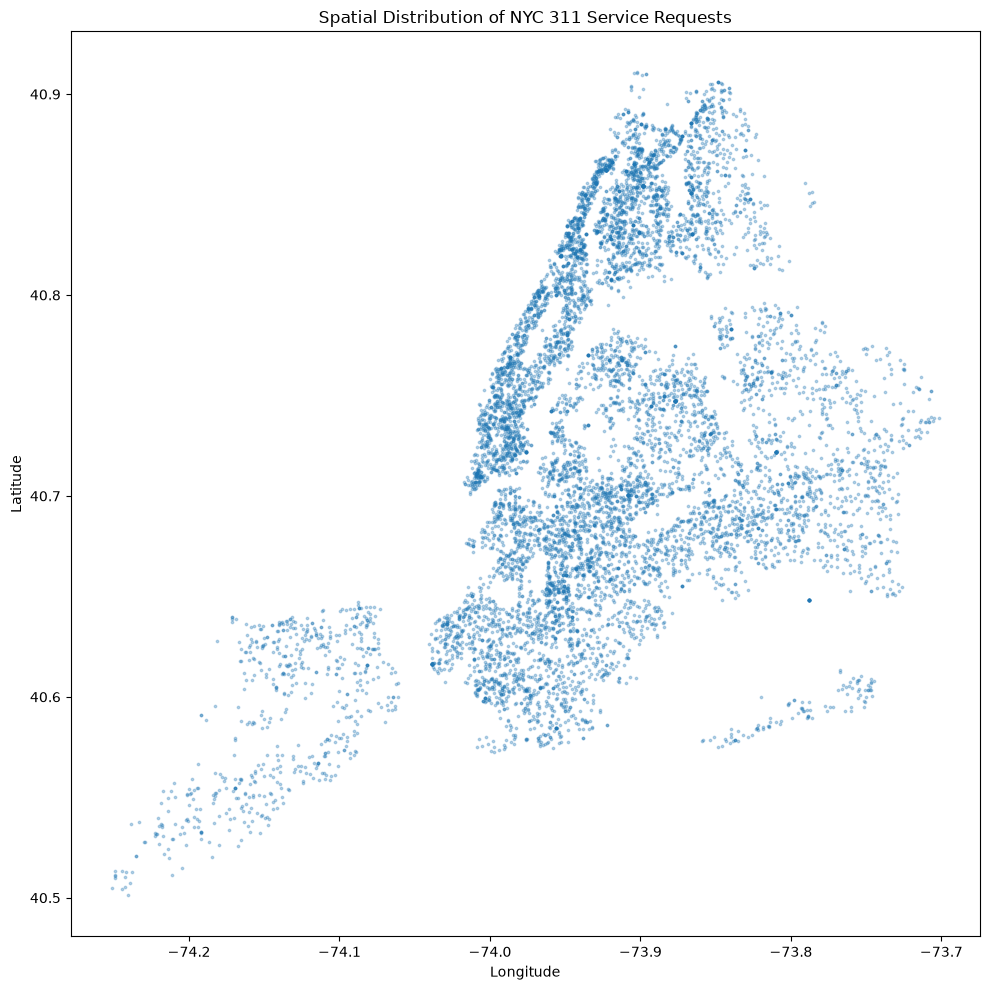

In [204]:
sample_geo = geo_df.sample(
    min(10000, len(geo_df)),
    random_state=42
)

plt.figure(figsize=(10, 10))

plt.scatter(
    sample_geo["longitude"],
    sample_geo["latitude"],
    s=3,
    alpha=0.3
)

plt.title("Spatial Distribution of NYC 311 Service Requests")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [205]:
cluster_data = geo_df.sample(
    min(20000, len(geo_df)),
    random_state=42
).copy()

coordinates = cluster_data[
    ["latitude", "longitude"]
].values

In [206]:
dbscan = DBSCAN(
    eps=0.003,
    min_samples=30
)

cluster_labels = dbscan.fit_predict(
    coordinates
)

cluster_data["cluster"] = cluster_labels

print(
    "Number of detected clusters:",
    len(set(cluster_labels)) -
    (1 if -1 in cluster_labels else 0)
)

print(
    "Noise points:",
    sum(cluster_labels == -1)
)

Number of detected clusters: 59
Noise points: 14079


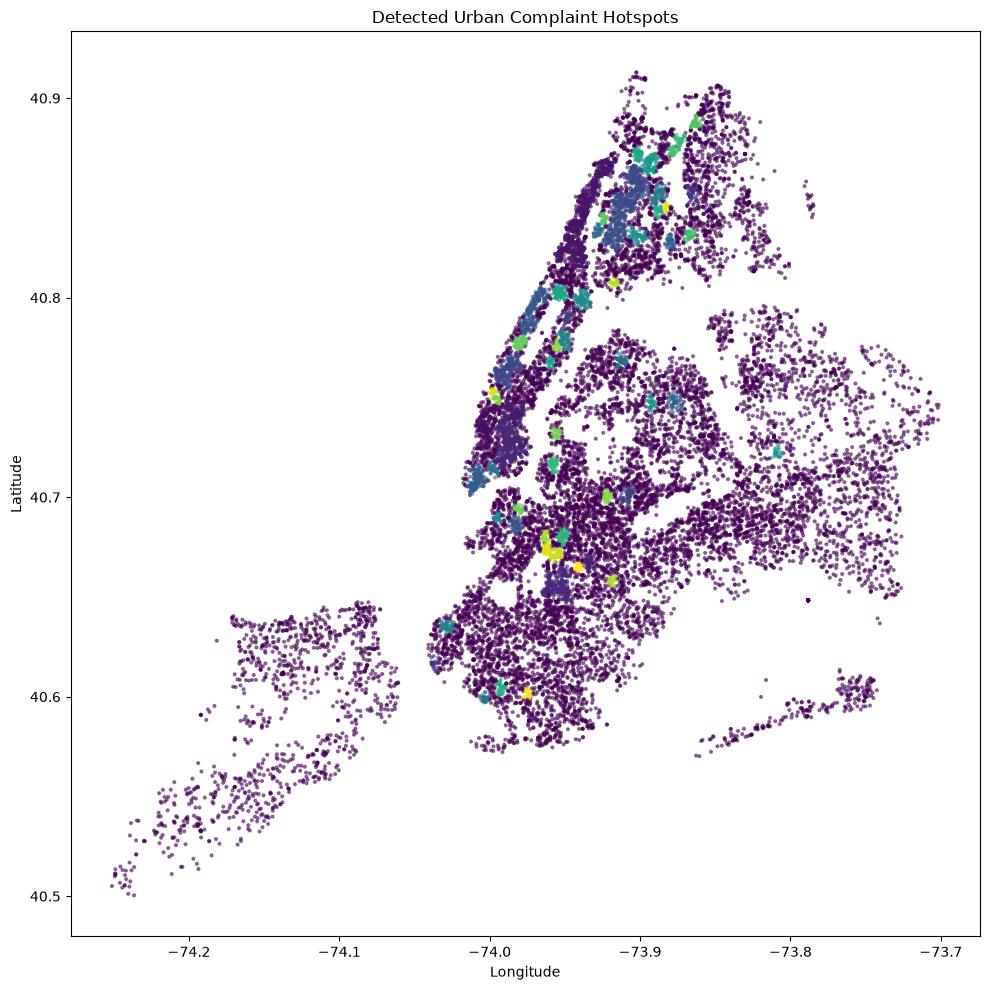

In [207]:
plt.figure(figsize=(10, 10))

plt.scatter(
    cluster_data["longitude"],
    cluster_data["latitude"],
    c=cluster_data["cluster"],
    s=4,
    alpha=0.5
)

plt.title("Detected Urban Complaint Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    "outputs/figures/hotspot_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [208]:
def _most_common(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else None


cluster_summary = (
    cluster_data[
        cluster_data["cluster"] != -1
    ]
    .groupby("cluster")
    .agg(
        complaint_count=("unique_key", "count"),
        avg_latitude=("latitude", "mean"),
        avg_longitude=("longitude", "mean"),
        primary_borough=("borough", _most_common),
        primary_complaint=("complaint_type", _most_common)
    )
    .sort_values(
        "complaint_count",
        ascending=False
    )
    .reset_index()
)

cluster_summary.head(10)

,cluster,complaint_count,avg_latitude,avg_longitude,primary_borough,primary_complaint
0,2,967,40.841045,-73.937286,MANHATTAN,HEAT/HOT WATER
1,12,444,40.854032,-73.904963,BRONX,HEAT/HOT WATER
2,5,430,40.726273,-73.987066,MANHATTAN,Noise - Residential
3,6,270,40.655807,-73.954215,BROOKLYN,HEAT/HOT WATER
4,1,255,40.735163,-74.002123,MANHATTAN,Request Large Bulky Item Collection
5,13,241,40.833116,-73.916084,BRONX,HEAT/HOT WATER
6,15,233,40.794227,-73.970521,MANHATTAN,HEAT/HOT WATER
7,11,214,40.763822,-73.988067,MANHATTAN,HEAT/HOT WATER
8,16,185,40.709045,-74.008578,MANHATTAN,Panhandling
9,3,181,40.742557,-73.983112,MANHATTAN,Noise - Helicopter


### Hotspot Interpretation

A hotspot represents a spatial cluster containing a relatively high
concentration of service requests.

Hotspot detection does not by itself establish that an area has a
more serious underlying urban problem. It identifies locations that
warrant further analytical investigation.

## 10. Urban Problem Score

The Urban Problem Score (UPS) is a project-defined analytical
index designed to compare urban areas using multiple measurable
indicators.

The score combines:

- complaint volume
- recent complaint growth
- average resolution time

All components are normalized before combining them.

In [209]:
borough_analysis = (
    df.groupby("borough")
    .agg(
        complaint_count=("unique_key", "count"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
    .reset_index()
)

borough_analysis

,borough,complaint_count,avg_resolution_hours
0,BRONX,88370,556.317107
1,BROOKLYN,153112,915.240904
2,MANHATTAN,98975,1075.860922
3,QUEENS,126365,673.949069
4,STATEN ISLAND,27394,672.576438
5,Unknown,3323,474.158953
6,Unspecified,2461,4149.788622


In [210]:
latest_date = df["created_date"].max()

recent_start = latest_date - pd.Timedelta(days=30)
previous_start = latest_date - pd.Timedelta(days=60)

recent_data = df[
    df["created_date"] >= recent_start
]

previous_data = df[
    (df["created_date"] >= previous_start) &
    (df["created_date"] < recent_start)
]

recent_counts = (
    recent_data["borough"]
    .value_counts()
)

previous_counts = (
    previous_data["borough"]
    .value_counts()
)

borough_analysis["recent_count"] = (
    borough_analysis["borough"]
    .map(recent_counts)
    .fillna(0)
)

borough_analysis["previous_count"] = (
    borough_analysis["borough"]
    .map(previous_counts)
    .fillna(0)
)

In [211]:
borough_analysis["growth_rate"] = np.where(
    borough_analysis["previous_count"] > 0,
    (
        (
            borough_analysis["recent_count"]
            -
            borough_analysis["previous_count"]
        )
        /
        borough_analysis["previous_count"]
    ) * 100,
    0
)

borough_analysis

,borough,complaint_count,avg_resolution_hours,recent_count,previous_count,growth_rate
0,BRONX,88370,556.317107,32888,31822,3.349884
1,BROOKLYN,153112,915.240904,57188,54639,4.665166
2,MANHATTAN,98975,1075.860922,36603,36284,0.879175
3,QUEENS,126365,673.949069,46865,45713,2.520071
4,STATEN ISLAND,27394,672.576438,10209,10302,-0.902737
5,Unknown,3323,474.158953,2331,620,275.967742
6,Unspecified,2461,4149.788622,791,947,-16.473073


In [212]:
def min_max_normalize(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            np.zeros(len(series)),
            index=series.index
        )

    return (series - minimum) / (maximum - minimum)

In [213]:
borough_analysis["volume_score"] = min_max_normalize(
    borough_analysis["complaint_count"]
)

borough_analysis["growth_score"] = min_max_normalize(
    borough_analysis["growth_rate"].clip(lower=0)
)

borough_analysis["resolution_score"] = min_max_normalize(
    borough_analysis["avg_resolution_hours"].fillna(0)
)

In [214]:
borough_analysis["urban_problem_score"] = (
    0.40 * borough_analysis["volume_score"]
    +
    0.25 * borough_analysis["growth_score"]
    +
    0.35 * borough_analysis["resolution_score"]
)

borough_analysis["urban_problem_score"] = (
    borough_analysis["urban_problem_score"] * 100
).round(2)

borough_analysis = borough_analysis.sort_values(
    "urban_problem_score",
    ascending=False
)

borough_analysis[
    [
        "borough",
        "complaint_count",
        "growth_rate",
        "avg_resolution_hours",
        "urban_problem_score"
    ]
]

,borough,complaint_count,growth_rate,avg_resolution_hours,urban_problem_score
1,BROOKLYN,153112,4.665166,915.240904,44.62
3,QUEENS,126365,2.520071,673.949069,35.03
6,Unspecified,2461,-16.473073,4149.788622,35.00
2,MANHATTAN,98975,0.879175,1075.860922,31.44
5,Unknown,3323,275.967742,474.158953,25.23
0,BRONX,88370,3.349884,556.317107,23.90
4,STATEN ISLAND,27394,-0.902737,672.576438,8.51


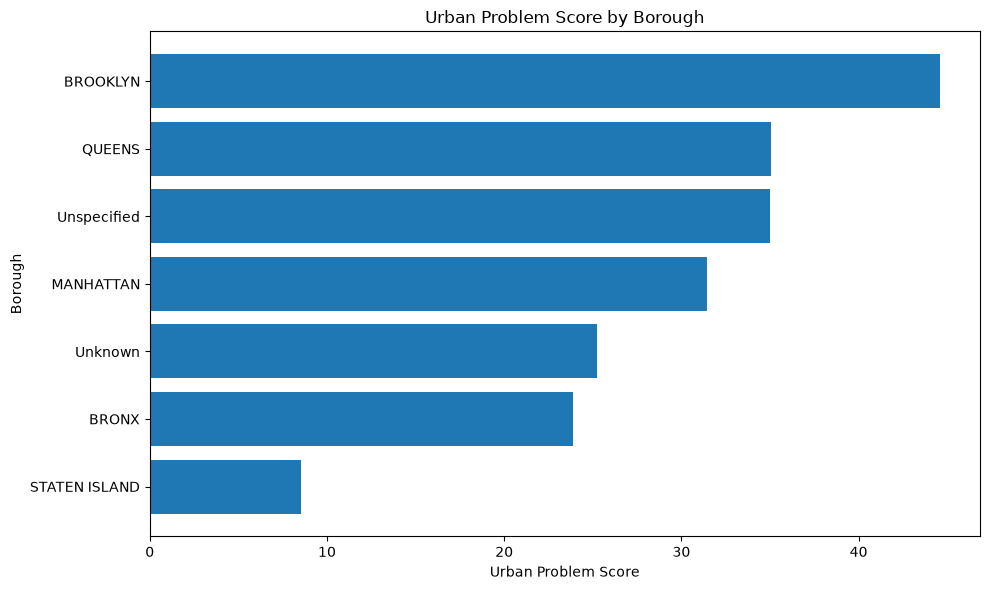

In [215]:
plt.figure(figsize=(10, 6))

score_plot = borough_analysis.sort_values(
    "urban_problem_score"
)

plt.barh(
    score_plot["borough"],
    score_plot["urban_problem_score"]
)

plt.title("Urban Problem Score by Borough")
plt.xlabel("Urban Problem Score")
plt.ylabel("Borough")

plt.tight_layout()

plt.savefig(
    "outputs/figures/urban_problem_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Predictive Analytics

CivicPulse AI uses historical service-request volume to predict
future daily request volume.

The prediction target is the number of service requests expected
on the next day.

Lag features and rolling averages are used as predictive variables.

In [216]:
df["created_date"] = pd.to_datetime(
    df["created_date"],
    errors="coerce"
)

# Remove records with invalid/missing dates
forecast_df = df.dropna(
    subset=["created_date"]
).copy()

print(
    "Valid date records:",
    len(forecast_df)
)

print(
    "Date range:",
    forecast_df["created_date"].min(),
    "to",
    forecast_df["created_date"].max()
)


# Create daily complaint counts
daily = (
    forecast_df
    .set_index("created_date")
    .resample("D")
    .size()
    .rename("complaint_count")
    .reset_index()
)

print("Daily records:", len(daily))


# Create lag features
daily["lag_1"] = daily["complaint_count"].shift(1)
daily["lag_7"] = daily["complaint_count"].shift(7)
daily["lag_14"] = daily["complaint_count"].shift(14)


# Create rolling averages
daily["rolling_7"] = (
    daily["complaint_count"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily["rolling_14"] = (
    daily["complaint_count"]
    .shift(1)
    .rolling(14)
    .mean()
)


# Calendar features
daily["day_of_week"] = (
    daily["created_date"].dt.dayofweek
)

daily["month"] = (
    daily["created_date"].dt.month
)


# Remove rows where lag/rolling features are unavailable
daily_model = (
    daily
    .dropna()
    .reset_index(drop=True)
)

print(
    "Records available for forecasting:",
    len(daily_model)
)


# Define features
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "day_of_week",
    "month"
]

X = daily_model[features]
y = daily_model["complaint_count"]


# Time-based 80/20 split
split_index = int(len(daily_model) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print("Training records:", len(X_train))
print("Testing records:", len(X_test))


# Safety check
if len(X_train) == 0:
    raise ValueError(
        "Training data is empty. More historical data is required."
    )

if len(X_test) == 0:
    raise ValueError(
        "Testing data is empty. More historical data is required."
    )


# Train Random Forest
forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(
    X_train,
    y_train
)


# Generate predictions
forecast_predictions = forecast_model.predict(
    X_test
)

print("Forecasting model trained successfully.")

Valid date records: 500000
Date range: 2020-01-01 00:00:00 to 2020-03-21 22:12:04
Daily records: 81
Records available for forecasting: 67
Training records: 53
Testing records: 14
Forecasting model trained successfully.


In [217]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Predictions:", len(forecast_predictions))
print("Next-day prediction can be generated from the latest features.")

X_train: (53, 7)
X_test: (14, 7)
Predictions: 14
Next-day prediction can be generated from the latest features.


In [218]:
# Predict the next day using the latest available data
latest_features = X.iloc[[-1]]

next_day_prediction = forecast_model.predict(
    latest_features
)[0]

print(
    "Predicted next-day complaint volume:",
    round(next_day_prediction)
)

Predicted next-day complaint volume: 5393


In [219]:
mae = mean_absolute_error(
    y_test,
    forecast_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast_predictions
    )
)

r2 = r2_score(
    y_test,
    forecast_predictions
)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error: 502.39
Root Mean Squared Error: 612.63
R² Score: 0.3848


In [220]:
prediction_results = pd.DataFrame({
    "Date": daily_model["created_date"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": forecast_predictions
})

prediction_results.head()

,Date,Actual,Predicted
53,2020-03-08,5592,5434.605
54,2020-03-09,7582,6447.785
55,2020-03-10,7005,6516.840
56,2020-03-11,7491,6497.735
57,2020-03-12,6735,6480.160


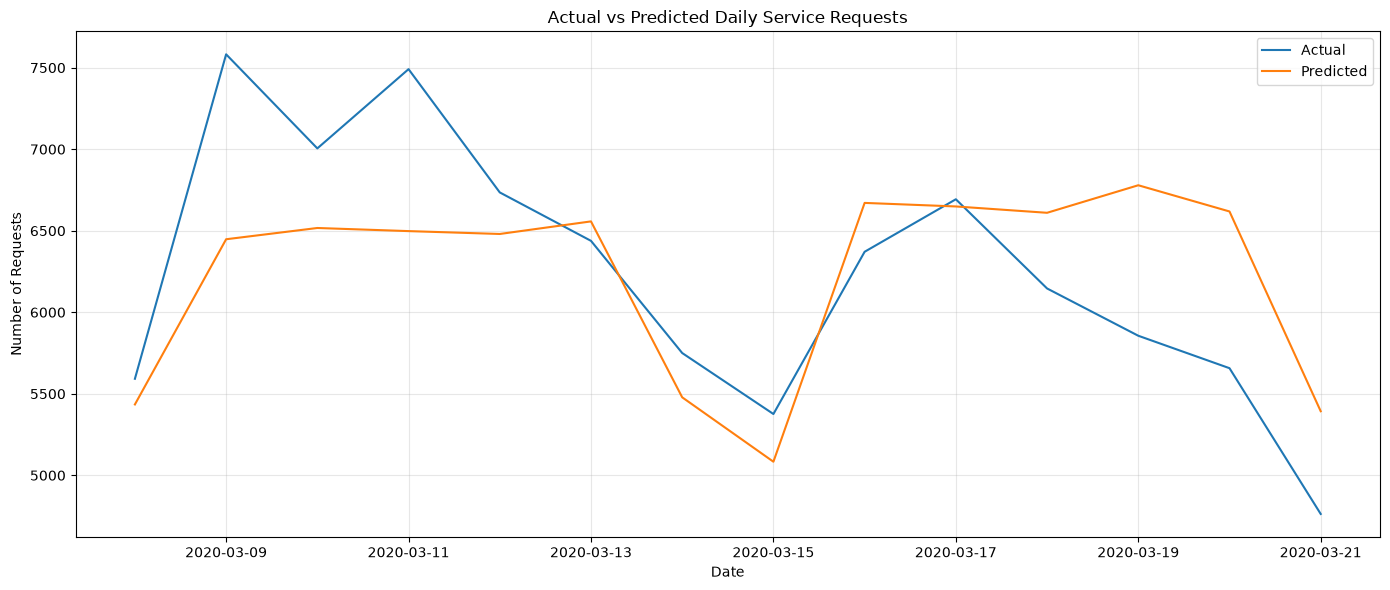

In [221]:
plt.figure(figsize=(14, 6))

plt.plot(
    prediction_results["Date"],
    prediction_results["Actual"],
    label="Actual"
)

plt.plot(
    prediction_results["Date"],
    prediction_results["Predicted"],
    label="Predicted"
)

plt.title("Actual vs Predicted Daily Service Requests")
plt.xlabel("Date")
plt.ylabel("Number of Requests")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "outputs/figures/prediction_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [222]:
feature_importance = pd.Series(
    forecast_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

day_of_week    0.596969
rolling_7      0.088686
lag_7          0.087893
rolling_14     0.079372
lag_1          0.075216
lag_14         0.066331
month          0.005534
dtype: float64

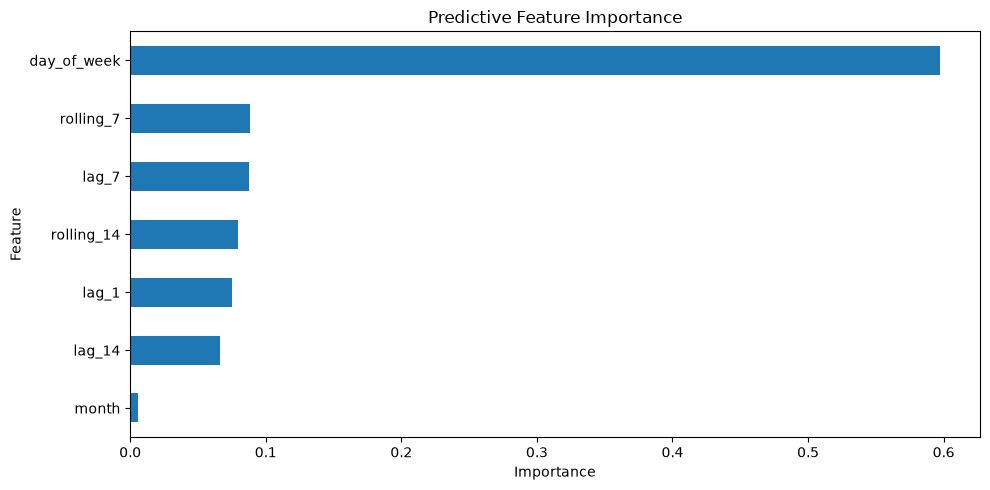

In [223]:
plt.figure(figsize=(10, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Predictive Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 12. AI-Assisted Insight Generation

The insight layer converts validated analytical results into
human-readable explanations.

The generation process is grounded in computed statistics rather
than allowing a language model to invent numerical results.

The analytical layer remains the source of truth.

In [224]:
top_problem = (
    df["complaint_type"]
    .value_counts()
    .index[0]
)

top_borough = (
    df["borough"]
    .value_counts()
    .index[0]
)

highest_score_area = (
    borough_analysis.iloc[0]["borough"]
)

highest_score = (
    borough_analysis.iloc[0]["urban_problem_score"]
)

average_resolution = (
    resolution_clean["resolution_hours"]
    .mean()
)

insight_facts = {
    "top_problem": top_problem,
    "top_borough": top_borough,
    "highest_score_area": highest_score_area,
    "highest_score": highest_score,
    "average_resolution_hours": round(
        average_resolution,
        2
    ),
    "predicted_next_day_requests": round(
        next_day_prediction
    )
}

insight_facts

{'top_problem': 'HEAT/HOT WATER',
 'top_borough': 'BROOKLYN',
 'highest_score_area': 'BROOKLYN',
 'highest_score': np.float64(44.62),
 'average_resolution_hours': np.float64(60.39),
 'predicted_next_day_requests': 5393}

In [225]:
def generate_insight(facts):

    insight = f"""
CivicPulse AI Analytical Insight

The most frequently recorded urban problem in the analyzed
dataset is "{facts['top_problem']}".

"{facts['top_borough']}" has the highest number of service
requests in the analyzed records.

The highest Urban Problem Score is associated with
"{facts['highest_score_area']}", with a score of
{facts['highest_score']} out of 100.

The average observed resolution time among records with
valid closure information is approximately
{facts['average_resolution_hours']} hours.

The predictive model estimates approximately
{facts['predicted_next_day_requests']} service requests
for the next observed day.

These findings describe patterns in the analyzed dataset and
should be interpreted as analytical indicators rather than
causal conclusions or official risk assessments.
"""

    return insight.strip()


print(
    generate_insight(insight_facts)
)

CivicPulse AI Analytical Insight

The most frequently recorded urban problem in the analyzed
dataset is "HEAT/HOT WATER".

"BROOKLYN" has the highest number of service
requests in the analyzed records.

The highest Urban Problem Score is associated with
"BROOKLYN", with a score of
44.62 out of 100.

The average observed resolution time among records with
valid closure information is approximately
60.39 hours.

The predictive model estimates approximately
5393 service requests
for the next observed day.

These findings describe patterns in the analyzed dataset and
should be interpreted as analytical indicators rather than
causal conclusions or official risk assessments.


In [226]:
metrics_df = pd.DataFrame({
    "Metric": [
        "NLP Classification Accuracy",
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score",
        "Estimated Requests"
    ],
    "Value": [
        round(nlp_accuracy, 4),
        round(mae, 2),
        round(rmse, 2),
        round(r2, 4),
        round(next_day_prediction)
    ]
})

metrics_df.to_csv(
    "outputs/final_metrics.csv",
    index=False
)

print("Final metrics saved successfully.")

Final metrics saved successfully.


## 13. Key Findings

The analysis provides insights into:

- the most frequent urban service-request categories
- differences in request volume across boroughs
- temporal changes in service-request activity
- patterns in service-request resolution time
- textual classification of problem details
- spatial concentrations of service requests
- comparative Urban Problem Scores
- predicted future service-request volume

The findings are descriptive and predictive indicators derived
from the analyzed dataset.

## 14. Limitations

1. The analysis uses a selected API sample rather than the complete
   NYC 311 dataset.

2. The dataset represents service requests that can be directed to
   specific agencies and therefore does not represent every possible
   urban issue.

3. The Urban Problem Score is a project-defined analytical index,
   not an official government metric.

4. Spatial clusters indicate concentration of reported requests,
   not necessarily the severity of an underlying problem.

5. Predictive performance depends on the historical period and
   sample used.

6. NLP classification performance depends on the availability and
   quality of textual problem-detail fields.

7. Correlation and prediction do not establish causation.

## 15. Future Scope

CivicPulse AI can be extended through:

- real-time 311 data ingestion
- larger historical datasets
- interactive geographic dashboards
- advanced transformer-based NLP
- category-specific forecasting
- weather and environmental data integration
- infrastructure datasets
- multilingual complaint analysis
- real-time anomaly detection
- LLM-based grounded insight generation
- deployment as a web-based urban analytics platform

## 16. Conclusion

CivicPulse AI demonstrates how data analytics, natural language
processing, geospatial analysis and machine learning can be
combined to transform large-scale urban service-request data into
structured insights.

The system analyzes complaint patterns, identifies spatial
concentrations, examines temporal trends, estimates resolution
patterns and predicts future service-request volume.

The project demonstrates an end-to-end data analytics workflow
from raw public data to analytical insights and predictive models.

## 17. Project Summary

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLP / TF-IDF
- DBSCAN clustering
- Machine Learning
- NYC OpenData API

### Core Components

1. Data Cleaning
2. Exploratory Data Analysis
3. Temporal Analytics
4. NLP Classification
5. Geospatial Hotspot Detection
6. Urban Problem Score
7. Predictive Analytics
8. AI-Assisted Insight Generation

In [230]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path(r"C:\Users\riya\Downloads\CivicPulse-AI-Final")
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(nlp_model, MODEL_DIR / "nlp_model.joblib")
joblib.dump(tfidf, MODEL_DIR / "tfidf_vectorizer.joblib")
joblib.dump(forecast_model, MODEL_DIR / "forecast_model.joblib")

print("Model artifacts saved successfully.")
print(f"Models saved to: {MODEL_DIR}")

Model artifacts saved successfully.
Models saved to: C:\Users\riya\Downloads\CivicPulse-AI-Final\models


In [231]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\riya\Downloads\CivicPulse-AI-Final")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


df.to_csv(
    DATA_DIR / "civicpulse_dataset.csv",
    index=False
)

borough_analysis.to_csv(
    OUTPUT_DIR / "urban_problem_scores.csv",
    index=False
)

cluster_summary.to_csv(
    OUTPUT_DIR / "hotspot_summary.csv",
    index=False
)

prediction_results.to_csv(
    OUTPUT_DIR / "prediction_results.csv",
    index=False
)

print("Dataset saved to:")
print(DATA_DIR / "civicpulse_dataset.csv")

print("\nOutput files saved to:")
print(OUTPUT_DIR)

print("\nAll files saved successfully.")

Dataset saved to:
C:\Users\riya\Downloads\CivicPulse-AI-Final\data\civicpulse_dataset.csv

Output files saved to:
C:\Users\riya\Downloads\CivicPulse-AI-Final\outputs

All files saved successfully.
